# **Extracting Information from Legal Documents Using RAG**

## Project Overview

This project processes and analyses a corpus of legal agreements to prepare them for a Retrieval-Augmented Generation (RAG) system. The workflow covers data loading, preprocessing, exploratory analysis, chunking, vector database creation, baseline RAG implementation, evaluation, and an adaptive document-aware retrieval improvement.

### **Business Value**

The project aims to leverage RAG to enhance legal document processing for businesses, law firms, and regulatory bodies. The key business objectives include:

* Faster Legal Research:  Reduce the time lawyers and compliance officers spend searching for relevant case laws, precedents, statutes, or contract clauses.
* Improved Contract Analysis:  Automatically extract key terms, obligations, and risks from lengthy contracts.
* Regulatory Compliance Monitoring:  Help businesses stay updated with legal and regulatory changes by retrieving relevant legal updates.
* Enhanced Decision-Making:  Provide accurate and context-aware legal insights to assist in risk assessment and legal strategy.


**Use Cases**
* Legal Chatbots
* Contract Review Automation
* Tracking Regulatory Changes and Compliance Monitoring
* Case Law Analysis of past judgments
* Due Diligence & Risk Assessment

### Repository Notes

This notebook assumes that the legal text corpus is available under `rag_legal/corpus`, the benchmark files are available under `rag_legal/benchmarks`, and the OpenAI API key is provided through a local `.env` file.

## 1. Data Loading, Preparation and Analysis

### **1.1 Data Understanding**

The dataset contains legal documents and contracts collected from various sources. The documents are present as text files (`.txt`) in the *corpus* folder.

There are four types of documents in the *courpus* folder, divided into four subfolders.
- `contractnli`: contains various non-disclosure and confidentiality agreements
- `cuad`: contains contracts with annotated legal clauses
- `maud`: contains various merger/acquisition contracts and agreements
- `privacy_qa`: a question-answering dataset containing privacy policies

The dataset also contains evaluation files in JSON format in the *benchmark* folder. The files contain the questions and their answers, along with sources. For the above folders, there is a `json` file: `contractnli.json`, `cuad.json`, `maud.json`. The file structure is as follows:

```
{
    "tests": [
        {
            "query": <question1>,
            "snippets": [{
                    "file_path": <source_file1>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 1>
                },
                {
                    "file_path": <source_file2>,
                    "span": [ begin_position, end_position ],
                    "answer": <relevant answer to the question 2>
                }, ....
            ]
        },
        {
            "query": <question2>,
            "snippets": [{<answer context for que 2>}]
        },
        ... <more queries>
    ]
}
```

### 1.2 Data Loading and Preprocessing

#### Loading Libraries

In [ ]:
# Optional dependency installation
# Uncomment and run these commands if the required packages are not already installed.
# !pip install -q langchain-openai
# !pip install -U -q langchain-community
# !pip install -U -q langchain-chroma
# !pip install -U -q datasets
# !pip install -U -q ragas
# !pip install -U -q rouge_score
# !pip install -q rank_bm25 sentence-transformers

In [ ]:
# Import essential libraries
import os
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LangChain imports
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

# Dataset and evaluation imports
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import Faithfulness, ContextPrecision, ContextRecall

#### 1.2.1 Loading Legal Text Files

In [ ]:
# Load the files as documents

corpus_path = Path("rag_legal/corpus")

documents = []
records = []

encodings = ["utf-8", "latin-1", "cp1252"]

for file_path in corpus_path.rglob("*.txt"):
    text = None
    
    for enc in encodings:
        try:
            with open(file_path, "r", encoding=enc) as f:
                text = f.read()
            break
        except UnicodeDecodeError:
            continue
    
    if text is None:
        continue
    
    dataset_name = file_path.parent.name
    
    metadata = {
        "file_name": file_path.name,
        "file_path": str(file_path),
        "dataset": dataset_name
    }
    
    documents.append(Document(page_content=text, metadata=metadata))
    
    records.append({
        "dataset": dataset_name,
        "file_name": file_path.name,
        "file_path": str(file_path),
        "text": text
    })

documents_df = pd.DataFrame(records)

print(f"Total text files loaded: {len(documents)}")
documents_df.head()

Total text files loaded: 645


,dataset,file_name,file_path,text
0,contractnli,01_Bosch-Automotive-Service-Solutions-Mutual-N...,rag_legal\corpus\contractnli\01_Bosch-Automoti...,MUTUAL NON-DISCLOSURE AGREEMENT\nBetween\nAND\...
1,contractnli,5-NSK-Confidentiality-Agreement-for-Suppliers.txt,rag_legal\corpus\contractnli\5-NSK-Confidentia...,NON-DISCLOSURE AGREEMENT\nThis Agreement is ef...
2,contractnli,ADVANIDE-NON-DISCLOSURE-AGREEMENT.txt,rag_legal\corpus\contractnli\ADVANIDE-NON-DISC...,NON-DISCLOSURE AGREEMENT\nR 2019/01\n(Pls. fil...
3,contractnli,AfriGIS_Client-NDA_Template_2019.txt,rag_legal\corpus\contractnli\AfriGIS_Client-ND...,CONFIDENTIALITY AND NON-DISCLOSURE AGREEMENT\n...
4,contractnli,AGProjects-NDA.txt,rag_legal\corpus\contractnli\AGProjects-NDA.txt,"Please fill in your contact details, sign on t..."


#### 1.2.2 Text Cleaning and Preprocessing

In [7]:
# Clean and preprocess the data

# Stopwords for analysis only
# Important legal words like no, not, shall, may, must are intentionally kept
stop_words = {
    "a", "an", "the", "and", "or", "but", "if", "while", "of", "at", "by", "for",
    "with", "about", "against", "between", "into", "through", "during", "before",
    "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off",
    "over", "under", "again", "further", "then", "once", "here", "there", "when",
    "where", "why", "how", "all", "any", "both", "each", "few", "more", "most",
    "other", "some", "such", "only", "own", "same", "so", "than", "too", "very",
    "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "do", "does", "did"
}

def clean_for_rag(text):
    try:
        if pd.isna(text) or text.strip() == "":
            return None

        # Remove email addresses
        text = re.sub(r'\S+@\S+', ' ', text)

        # Remove phone numbers
        text = re.sub(r'\+?\d[\d\s\-\(\)]{7,}\d', ' ', text)

        # Remove URLs
        text = re.sub(r'http\S+|www\S+', ' ', text)

        # Remove excessive special characters but preserve useful legal punctuation
        text = re.sub(r'[^A-Za-z0-9\s\.\,\;\:\-\(\)]', ' ', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    except Exception:
        return None


def clean_for_analysis(text):
    try:
        if text is None or pd.isna(text) or text.strip() == "":
            return None

        # Convert to lowercase
        text = text.lower()

        # Remove punctuation/special characters for word-level analysis
        text = re.sub(r'[^a-z0-9\s]', ' ', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        # Remove stopwords
        words = text.split()
        words = [word for word in words if word not in stop_words]

        return " ".join(words)

    except Exception:
        return None


# Apply preprocessing
documents_df["rag_text"] = documents_df["text"].apply(clean_for_rag)
documents_df["analysis_text"] = documents_df["rag_text"].apply(clean_for_analysis)

# Log and remove problematic files
problematic_files = documents_df[
    documents_df["rag_text"].isna() | documents_df["analysis_text"].isna()
][["file_name", "file_path"]]

cleaned_documents_df = documents_df.dropna(subset=["rag_text", "analysis_text"]).copy()

# Create cleaned LangChain documents for RAG
cleaned_documents = [
    Document(
        page_content=row["rag_text"],
        metadata={
            "file_name": row["file_name"],
            "file_path": row["file_path"],
            "dataset": row["dataset"]
        }
    )
    for _, row in cleaned_documents_df.iterrows()
]

print(f"Original documents: {len(documents_df)}")
print(f"Cleaned documents: {len(cleaned_documents_df)}")
print(f"Problematic files skipped: {len(problematic_files)}")

cleaned_documents_df.head()

Original documents: 645
Cleaned documents: 645
Problematic files skipped: 0


,dataset,file_name,file_path,text,cleaned_text,rag_text,analysis_text
0,contractnli,01_Bosch-Automotive-Service-Solutions-Mutual-N...,rag_legal\corpus\contractnli\01_Bosch-Automoti...,MUTUAL NON-DISCLOSURE AGREEMENT\nBetween\nAND\...,mutual non disclosure agreement subject matter...,MUTUAL NON-DISCLOSURE AGREEMENT Between AND Su...,mutual non disclosure agreement subject matter...
1,contractnli,5-NSK-Confidentiality-Agreement-for-Suppliers.txt,rag_legal\corpus\contractnli\5-NSK-Confidentia...,NON-DISCLOSURE AGREEMENT\nThis Agreement is ef...,non disclosure agreement this agreement effect...,NON-DISCLOSURE AGREEMENT This Agreement is eff...,non disclosure agreement this agreement effect...
2,contractnli,ADVANIDE-NON-DISCLOSURE-AGREEMENT.txt,rag_legal\corpus\contractnli\ADVANIDE-NON-DISC...,NON-DISCLOSURE AGREEMENT\nR 2019/01\n(Pls. fil...,non disclosure agreement r 2019 01 pls fill fo...,NON-DISCLOSURE AGREEMENT R 2019 01 (Pls. fill ...,non disclosure agreement r 2019 01 pls fill fo...
3,contractnli,AfriGIS_Client-NDA_Template_2019.txt,rag_legal\corpus\contractnli\AfriGIS_Client-ND...,CONFIDENTIALITY AND NON-DISCLOSURE AGREEMENT\n...,confidentiality non disclosure agreement afrig...,CONFIDENTIALITY AND NON-DISCLOSURE AGREEMENT b...,confidentiality non disclosure agreement afrig...
4,contractnli,AGProjects-NDA.txt,rag_legal\corpus\contractnli\AGProjects-NDA.txt,"Please fill in your contact details, sign on t...",please fill your contact details sign last pag...,"Please fill in your contact details, sign on t...",please fill your contact details sign last pag...


### 1.3 Exploratory Data Analysis

#### 1.3.1 Document Length Analysis

In [8]:
# Calculate the average, maximum and minimum document length.

cleaned_documents_df["document_length"] = cleaned_documents_df["rag_text"].apply(lambda x: len(x.split()))

avg_length = cleaned_documents_df["document_length"].mean()
max_length = cleaned_documents_df["document_length"].max()
min_length = cleaned_documents_df["document_length"].min()

print(f"Average document length: {avg_length:.2f} words")
print(f"Maximum document length: {max_length} words")
print(f"Minimum document length: {min_length} words")

Average document length: 15294.20 words
Maximum document length: 156894 words
Minimum document length: 228 words


#### 1.3.2 Word Frequency Analysis

In [9]:
# Find frequency of occurence of words

from collections import Counter

# Combine all preprocessed analysis text
all_text = " ".join(cleaned_documents_df["analysis_text"].dropna())

# Tokenise into words
words = all_text.split()

# Keep meaningful words only
words = [word for word in words if word.isalpha() and len(word) > 1]

# Count word frequencies
word_freq = Counter(words)

# 20 most common words
most_common_words = word_freq.most_common(20)

# 20 least common words
least_common_words = sorted(word_freq.items(), key=lambda x: x[1])[:20]

# Convert to dataframes
most_common_df = pd.DataFrame(most_common_words, columns=["word", "frequency"])
least_common_df = pd.DataFrame(least_common_words, columns=["word", "frequency"])

print("20 Most Common Words:")
display(most_common_df)

print("20 Least Common Words:")
display(least_common_df)

20 Most Common Words:


,word,frequency
0,company,135780
1,shall,95668
2,agreement,92971
3,as,87740
4,this,86385
5,that,73312
6,section,65873
7,its,58964
8,parent,54884
9,not,53203


20 Least Common Words:


,word,frequency
0,maidenhead,1
1,pls,1
2,klingenweg,1
3,temasek,1
4,walluf,1
5,suntec,1
6,natick,1
7,roessner,1
8,gazetted,1
9,customised,1


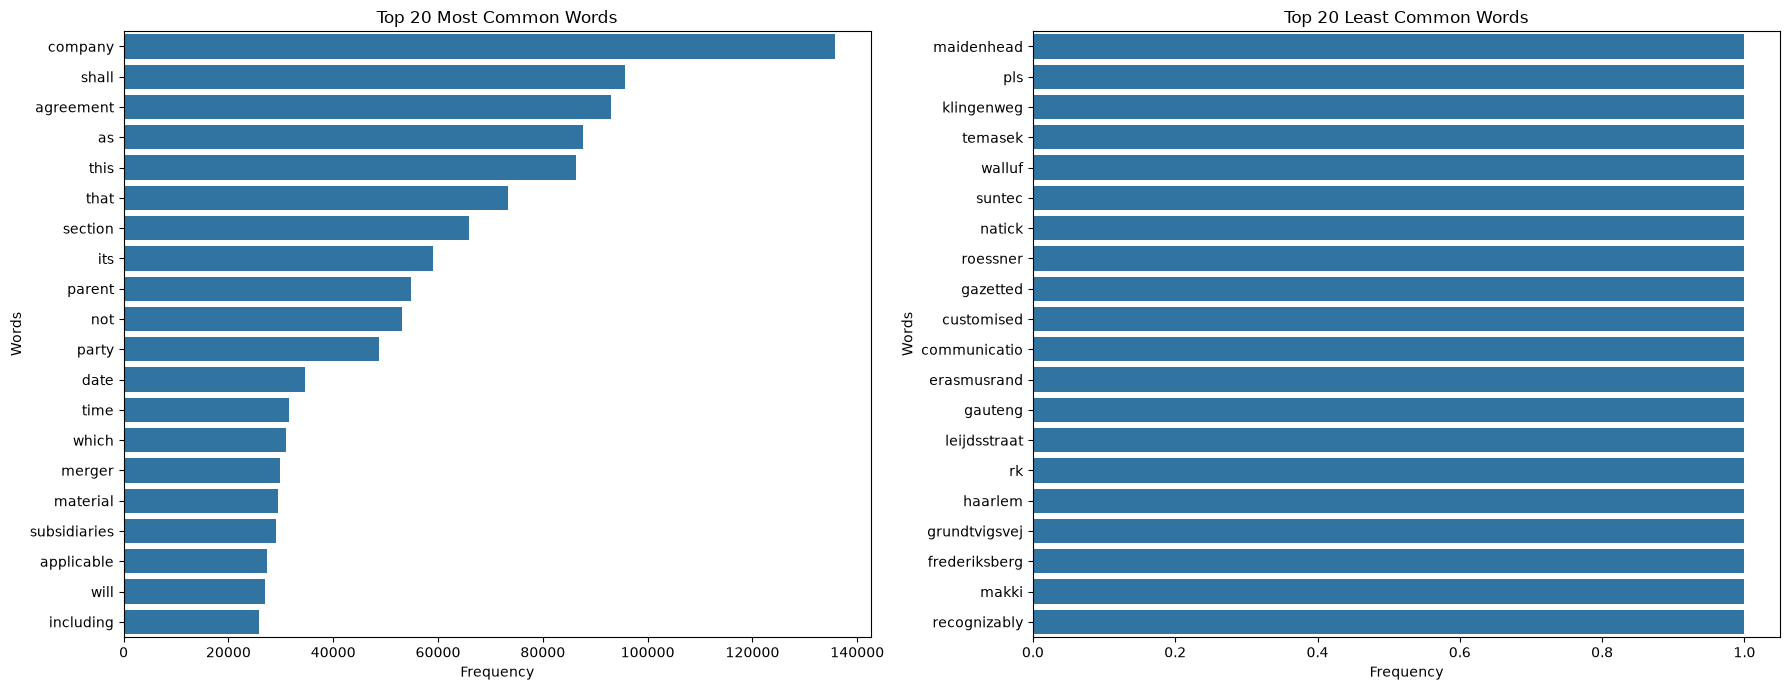

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 20 most common words
sns.barplot(
    data=most_common_df,
    x="frequency",
    y="word",
    ax=axes[0]
)

axes[0].set_title("Top 20 Most Common Words")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Words")

# 20 least common words
sns.barplot(
    data=least_common_df,
    x="frequency",
    y="word",
    ax=axes[1]
)

axes[1].set_title("Top 20 Least Common Words")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Words")

plt.tight_layout()
plt.show()

#### 1.3.3 TF-IDF Document Similarity Analysis

In [11]:
# Transform the page contents of documents

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

first_10_docs = cleaned_documents_df.head(10).copy()

vectorizer = TfidfVectorizer(max_features=5000)

tfidf_first_10 = vectorizer.fit_transform(first_10_docs["analysis_text"])

# Compute similarity scores
similarity_first_10 = cosine_similarity(tfidf_first_10)

similarity_first_10_df = pd.DataFrame(
    similarity_first_10,
    index=[f"Doc_{i+1}" for i in range(10)],
    columns=[f"Doc_{i+1}" for i in range(10)]
)

display(similarity_first_10_df.round(3))

first_10_docs[["file_name", "dataset"]].reset_index(drop=True)

,Doc_1,Doc_2,Doc_3,Doc_4,Doc_5,Doc_6,Doc_7,Doc_8,Doc_9,Doc_10
Doc_1,1.000,0.658,0.547,0.580,0.592,0.617,0.745,0.424,0.597,0.322
Doc_2,0.658,1.000,0.687,0.748,0.728,0.759,0.794,0.401,0.725,0.283
Doc_3,0.547,0.687,1.000,0.610,0.633,0.656,0.661,0.304,0.618,0.231
Doc_4,0.580,0.748,0.610,1.000,0.628,0.653,0.664,0.348,0.639,0.292
Doc_5,0.592,0.728,0.633,0.628,1.000,0.728,0.660,0.353,0.697,0.228
Doc_6,0.617,0.759,0.656,0.653,0.728,1.000,0.703,0.388,0.701,0.262
Doc_7,0.745,0.794,0.661,0.664,0.660,0.703,1.000,0.355,0.652,0.236
Doc_8,0.424,0.401,0.304,0.348,0.353,0.388,0.355,1.000,0.389,0.272
Doc_9,0.597,0.725,0.618,0.639,0.697,0.701,0.652,0.389,1.000,0.270
Doc_10,0.322,0.283,0.231,0.292,0.228,0.262,0.236,0.272,0.270,1.000


,file_name,dataset
0,01_Bosch-Automotive-Service-Solutions-Mutual-N...,contractnli
1,5-NSK-Confidentiality-Agreement-for-Suppliers.txt,contractnli
2,ADVANIDE-NON-DISCLOSURE-AGREEMENT.txt,contractnli
3,AfriGIS_Client-NDA_Template_2019.txt,contractnli
4,AGProjects-NDA.txt,contractnli
5,amc-general-mutual-non-disclosure-agreement-en...,contractnli
6,Aspiegel_NDA_template.txt,contractnli
7,BCG-Mutual-NDA.txt,contractnli
8,BT_NDA.txt,contractnli
9,CBP%20Non-Disclosure%20Form_October2018.txt,contractnli


In [12]:
# create a list of 10 random integers

import random

random.seed(42)

random_indices = random.sample(range(len(cleaned_documents_df)), 10)

random_indices

[114, 25, 281, 250, 228, 142, 104, 558, 89, 604]

In [13]:
# Compute similarity scores for 10 random documents

random_10_docs = cleaned_documents_df.iloc[random_indices].copy()

vectorizer_random = TfidfVectorizer(max_features=5000)

tfidf_random_10 = vectorizer_random.fit_transform(random_10_docs["analysis_text"])

similarity_random_10 = cosine_similarity(tfidf_random_10)

similarity_random_10_df = pd.DataFrame(
    similarity_random_10,
    index=[f"Doc_{i+1}" for i in range(10)],
    columns=[f"Doc_{i+1}" for i in range(10)]
)

display(similarity_random_10_df.round(3))

random_10_docs[["file_name", "dataset"]].reset_index(drop=True)

,Doc_1,Doc_2,Doc_3,Doc_4,Doc_5,Doc_6,Doc_7,Doc_8,Doc_9,Doc_10
Doc_1,1.000,0.156,0.207,0.192,0.212,0.229,0.259,0.226,0.210,0.202
Doc_2,0.156,1.000,0.122,0.097,0.099,0.114,0.124,0.139,0.169,0.134
Doc_3,0.207,0.122,1.000,0.159,0.207,0.166,0.211,0.192,0.166,0.174
Doc_4,0.192,0.097,0.159,1.000,0.151,0.136,0.194,0.149,0.140,0.132
Doc_5,0.212,0.099,0.207,0.151,1.000,0.193,0.188,0.193,0.168,0.173
Doc_6,0.229,0.114,0.166,0.136,0.193,1.000,0.196,0.168,0.147,0.156
Doc_7,0.259,0.124,0.211,0.194,0.188,0.196,1.000,0.237,0.156,0.213
Doc_8,0.226,0.139,0.192,0.149,0.193,0.168,0.237,1.000,0.168,0.890
Doc_9,0.210,0.169,0.166,0.140,0.168,0.147,0.156,0.168,1.000,0.151
Doc_10,0.202,0.134,0.174,0.132,0.173,0.156,0.213,0.890,0.151,1.000


,file_name,dataset
0,ANIXABIOSCIENCESINC_06_09_2020-EX-10.1-COLLABO...,cuad
1,Focus-Group-APIC-Seattle-Confidentiality-Agree...,contractnli
2,ImineCorp_20180725_S-1_EX-10.5_11275970_EX-10....,cuad
3,"GRIDIRONBIONUTRIENTS,INC_02_05_2020-EX-10.3-SU...",cuad
4,"FTENETWORKS,INC_02_18_2016-EX-99.4-STRATEGIC A...",cuad
5,BIOAMBERINC_04_10_2013-EX-10.34-DEVELOPMENT AG...,cuad
6,AimmuneTherapeuticsInc_20200205_8-K_EX-10.3_11...,cuad
7,"Eidos Therapeutics, Inc._BridgeBio Pharma, Inc...",maud
8,VELCO%20NDA%20rev0%20Dec%2014%202015.txt,contractnli
9,"People_s United Financial, Inc._M_T Bank Corpo...",maud


The first 10 documents show relatively high similarity scores because they all belong to the contractnli dataset, which mainly contains NDA and confidentiality agreements. Such documents often share repeated legal vocabulary, clause structures, and standard confidentiality terms.

For the 10 random documents, most similarity scores are lower because the documents are selected from different datasets such as CUAD, ContractNLI, and MAUD. This indicates greater diversity in document type and legal content.

However, one pair of random documents shows very high similarity, with a score of 0.890 between Doc_8 and Doc_10. This may indicate duplicate or highly similar contractual clauses. Such similarity analysis is useful for RAG preparation because it helps identify repeated content, potential duplicates, and documents that may need careful chunking or deduplication before retrieval.

### 1.4 Document Creation and Chunking

#### 1.4.1 Chunking Legal Documents

In [14]:
# Process files and generate chunks

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", " ", ""]
)

chunks = text_splitter.split_documents(cleaned_documents)

chunk_records = []

for i, chunk in enumerate(chunks):
    chunk.metadata["chunk_id"] = i
    
    chunk_records.append({
        "chunk_id": i,
        "file_name": chunk.metadata.get("file_name"),
        "file_path": chunk.metadata.get("file_path"),
        "dataset": chunk.metadata.get("dataset"),
        "chunk_text": chunk.page_content,
        "chunk_length": len(chunk.page_content.split())
    })

chunks_df = pd.DataFrame(chunk_records)

print(f"Total original documents: {len(cleaned_documents)}")
print(f"Total chunks created: {len(chunks)}")
print(f"Average chunk length: {chunks_df['chunk_length'].mean():.2f} words")

chunks_df.head()

Total original documents: 645
Total chunks created: 85880
Average chunk length: 126.39 words


,chunk_id,file_name,file_path,dataset,chunk_text,chunk_length
0,0,01_Bosch-Automotive-Service-Solutions-Mutual-N...,rag_legal\corpus\contractnli\01_Bosch-Automoti...,contractnli,MUTUAL NON-DISCLOSURE AGREEMENT Between AND Su...,132
1,1,01_Bosch-Automotive-Service-Solutions-Mutual-N...,rag_legal\corpus\contractnli\01_Bosch-Automoti...,contractnli,. III. Both parties recognize the value of the...,139
2,2,01_Bosch-Automotive-Service-Solutions-Mutual-N...,rag_legal\corpus\contractnli\01_Bosch-Automoti...,contractnli,". Confidential Information includes, but is no...",106
3,3,01_Bosch-Automotive-Service-Solutions-Mutual-N...,rag_legal\corpus\contractnli\01_Bosch-Automoti...,contractnli,. Recipient agrees to limit disclosure of Conf...,117
4,4,01_Bosch-Automotive-Service-Solutions-Mutual-N...,rag_legal\corpus\contractnli\01_Bosch-Automoti...,contractnli,. Recipient shall not without Disclosing Party...,138


The documents were split into overlapping chunks using RecursiveCharacterTextSplitter. A chunk size of 1000 characters with 200 characters overlap was used to preserve context across neighbouring chunks. This is suitable for RAG because legal agreements often contain long clauses, and overlap helps avoid losing important clause-level meaning during retrieval.

## 2. Vector Database and RAG Chain Creation

### 2.1 Vector Embedding and Vector Database Creation

#### 2.1.1 Embedding Function Initialisation

In [23]:
# Fetch your API Key as an environment variable (or load it directly if variable naming is conventional)

from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    print("OpenAI API key loaded successfully.")
else:
    print("OpenAI API key not found. Please check your .env file.")

OpenAI API key loaded successfully.


In [ ]:
# Initialise an embedding function

embedding_function = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=os.environ["OPENAI_API_KEY"]
)

print("Embedding function initialised successfully.")

Embedding function initialised successfully.


#### 2.1.2 Chroma Vector Database Creation

In [ ]:
# Add Chunks to vector DB

import shutil

# Directory to store the vector database
persist_directory = "legal_agreement_vector_db"

# Remove existing DB folder if rerunning the notebook
if os.path.exists(persist_directory):
    shutil.rmtree(persist_directory)

# Create Chroma vector database from chunks
vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_function,
    persist_directory=persist_directory,
    collection_name="legal_agreements_collection"
)

print("Vector database created successfully.")
print(f"Vector DB directory: {persist_directory}")
print(f"Total chunks stored: {vector_db._collection.count()}")

Vector database created successfully.
Vector DB directory: legal_agreement_vector_db
Total chunks stored: 85880


### 2.2 RAG Chain Creation

#### 2.2.1 Baseline RAG Pipeline

In [ ]:
# Create a RAG chain

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# Convert vector DB into retriever
retriever = vector_db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

# Function to format retrieved documents
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Prompt template
prompt = ChatPromptTemplate.from_template("""
You are a legal document question-answering assistant.

Answer the question using only the context provided below.
If the answer is not available in the context, say that the provided context does not contain enough information.

Context:
{context}

Question:
{question}

Answer:
""")

# LLM
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# Complete RAG chain
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

print("RAG chain created successfully.")

RAG chain created successfully.


#### 2.2.2 Question Answering Function

In [32]:
# Create a function for question answering

def generate_answer(question):
    # Retrieve relevant source documents
    source_docs = retriever.invoke(question)
    
    # Generate answer using RAG chain
    answer = rag_chain.invoke(question)
    
    print("Question:")
    print(question)
    print("\nAnswer:")
    print(answer)
    
    print("\nSource Documents:")
    for i, doc in enumerate(source_docs, start=1):
        print(f"\nSource {i}")
        print(f"File name: {doc.metadata.get('file_name')}")
        print(f"Dataset: {doc.metadata.get('dataset')}")
        print(f"File path: {doc.metadata.get('file_path')}")
        print("Content preview:")
        print(doc.page_content[:500])
    
    return {
        "question": question,
        "answer": answer,
        "source_documents": source_docs
    }

In [33]:
# Example question
question ="Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"

response = generate_answer(question)

Question:
Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?

Answer:
Yes, the document indicates that the Receiving Party shall not acquire any right, title, or interest in or to any Confidential Information of the Disclosing Party by virtue of its disclosure under the Agreement.

Source Documents:

Source 1
File name: Sony%20Pictures%20Television%20NDA%20(Executed).txt
Dataset: contractnli
File path: rag_legal\corpus\contractnli\Sony%20Pictures%20Television%20NDA%20(Executed).txt
Content preview:
. Additionally, this Agreement does not constitute or create any obligation of either party to provide any Confidential Information or other information to the other party, rather it merely defines the duties and obligations of each party and its Representatives with respect to the Confidential Information to the extent Confidential Information may b

## 3. RAG Evaluation

### 3.1 Evaluation Setup and Results

#### 3.1.1 Benchmark Question and Ground Truth Extraction

In [34]:
# Create a question set by taking all the questions from the benchmark data
# Also create a ground truth/answer set

benchmark_path = Path("rag_legal/benchmarks")

benchmark_records = []

for json_file in benchmark_path.rglob("*.json"):
    with open(json_file, "r", encoding="utf-8") as f:
        benchmark_data = json.load(f)
    
    dataset_name = json_file.stem
    
    for test in benchmark_data.get("tests", []):
        question = test.get("query", "")
        snippets = test.get("snippets", [])
        
        answers = []
        source_files = []
        spans = []
        
        for snippet in snippets:
            answer = snippet.get("answer", "")
            file_path = snippet.get("file_path", "")
            span = snippet.get("span", "")
            
            if answer:
                answers.append(answer)
            if file_path:
                source_files.append(file_path)
            if span:
                spans.append(span)
        
        ground_truth = " ".join(answers)
        
        benchmark_records.append({
            "dataset": dataset_name,
            "question": question,
            "ground_truth": ground_truth,
            "answers": answers,
            "source_files": source_files,
            "spans": spans
        })

benchmark_df = pd.DataFrame(benchmark_records)

question_set = benchmark_df["question"].tolist()
answer_set = benchmark_df["ground_truth"].tolist()

print(f"Total benchmark questions: {len(question_set)}")
print(f"Total ground truth answers: {len(answer_set)}")

benchmark_df.head()

Total benchmark questions: 11714
Total ground truth answers: 11714


,dataset,question,ground_truth,answers,source_files,spans
0,contractnli,Consider the Non-Disclosure Agreement between ...,"Any and all proprietary rights, including but ...","[Any and all proprietary rights, including but...",[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,"[[11461, 11963]]"
1,contractnli,Consider the Non-Disclosure Agreement between ...,“Confidential Information” means any Idea disc...,[“Confidential Information” means any Idea dis...,[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,"[[7752, 8016]]"
2,contractnli,Consider the Non-Disclosure Agreement between ...,Notwithstanding the termination of this Agreem...,[Notwithstanding the termination of this Agree...,[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,"[[12076, 12328]]"
3,contractnli,Consider the Non-Disclosure Agreement between ...,"At Organiser’s first request, Mentor shall: (d...","[At Organiser’s first request, Mentor shall:, ...",[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,"[[10013, 10056], [10391, 10729]]"
4,contractnli,Consider the Non-Disclosure Agreement between ...,Mentor shall not disclose any Confidential Inf...,[Mentor shall not disclose any Confidential In...,[contractnli/CopAcc_NDA-and-ToP-Mentors_2.0_20...,"[[8667, 8837]]"


#### 3.1.2 RAG Evaluation Function

In [ ]:
# Compatibility patch for RAGAS in environments where the older VertexAI import path is unavailable

import sys
import types

dummy_chat = types.ModuleType("langchain_community.chat_models.vertexai")
dummy_chat.ChatVertexAI = type("ChatVertexAI", (object,), {})
sys.modules["langchain_community.chat_models.vertexai"] = dummy_chat

import langchain_community.llms
langchain_community.llms.VertexAI = type("VertexAI", (object,), {})

In [ ]:
# Function to evaluate the RAG pipeline

from ragas.llms import LangchainLLMWrapper
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))

def normalise_path(path):
    return os.path.basename(str(path)).lower().replace("\\", "/")


def evaluate_rag_pipeline(benchmark_df, sample_size=10, k=4):
    eval_records = []
    retrieval_records = []

    eval_df = benchmark_df.head(sample_size).copy()

    for _, row in eval_df.iterrows():
        question = row["question"]
        ground_truth = row["ground_truth"]
        expected_sources = row["source_files"]

        retrieved_docs = retriever.invoke(question)[:k]

        contexts = [doc.page_content for doc in retrieved_docs]

        generated_answer = rag_chain.invoke(question)

        retrieved_sources = [
            doc.metadata.get("file_path", doc.metadata.get("file_name", ""))
            for doc in retrieved_docs
        ]

        expected_source_names = set(
            normalise_path(src) for src in expected_sources
        )

        retrieved_source_names = [
            normalise_path(src) for src in retrieved_sources
        ]

        relevant_retrieved = sum(
            1 for src in retrieved_source_names if src in expected_source_names
        )

        precision_at_k = relevant_retrieved / k if k > 0 else 0

        if len(expected_source_names) > 0:
            recall_at_k = len(
                set(retrieved_source_names).intersection(expected_source_names)
            ) / len(expected_source_names)
        else:
            recall_at_k = 0

        eval_records.append({
            "question": question,
            "answer": generated_answer,
            "contexts": contexts,
            "ground_truth": ground_truth
        })

        retrieval_records.append({
            "question": question,
            "expected_sources": expected_sources,
            "retrieved_sources": retrieved_sources,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k
        })

    ragas_dataset = Dataset.from_list(eval_records)
    ragas_dataset

    ragas_result = evaluate(
        ragas_dataset,
        metrics=[
            Faithfulness(llm=evaluator_llm),
            ContextPrecision(llm=evaluator_llm),
            ContextRecall(llm=evaluator_llm),
        ]
    )

    retrieval_metrics_df = pd.DataFrame(retrieval_records)

    ragas_result_df = ragas_result.to_pandas()

    print("RAGAS Evaluation Results:")
    print(ragas_result)

    print("\nRetrieval Quality Metrics:")
    print(f"Average Precision@{k}: {retrieval_metrics_df['precision_at_k'].mean():.3f}")
    print(f"Average Recall@{k}: {retrieval_metrics_df['recall_at_k'].mean():.3f}")

    return ragas_result, retrieval_metrics_df, ragas_result_df

#### 3.1.3 Baseline Evaluation Results

In [ ]:
# Evaluate the RAG pipeline

sampled_benchmark_df = benchmark_df.sample(n=10, random_state=42).reset_index(drop=True)

ragas_result, retrieval_metrics_df, ragas_result_df = evaluate_rag_pipeline(
    sampled_benchmark_df,
    sample_size=10,
    k=4
)

retrieval_metrics_df.head()

Evaluating: 100%|██████████| 30/30 [00:30<00:00,  1.02s/it]

RAGAS Evaluation Results:
{'faithfulness': 0.3133, 'context_precision': 0.7750, 'context_recall': 0.5500}

Retrieval Quality Metrics:
Average Precision@4: 0.625
Average Recall@4: 0.800


,question,expected_sources,retrieved_sources,precision_at_k,recall_at_k
0,"Consider the Merger Agreement between ""Columbi...",[maud/Columbia_Property_Pacific_Investment_Man...,[rag_legal\corpus\maud\Columbia_Property_Pacif...,1.00,1.0
1,Consider the Acquisition Agreement between Par...,"[maud/Alexion Pharmaceuticals, Inc._AstraZenec...","[rag_legal\corpus\maud\Viela Bio, Inc._Horizon...",0.00,0.0
2,Consider the Non-Disclosure Agreement between ...,[contractnli/sample-nrel-bilateral-nda-templat...,[rag_legal\corpus\contractnli\sample-nrel-bila...,1.00,1.0
3,Consider the Promotion Agreement between Go Ca...,[cuad/GOCALLINC_03_30_2000-EX-10.7-Promotion A...,[rag_legal\corpus\cuad\GOCALLINC_03_30_2000-EX...,1.00,1.0
4,Consider the Intellectual Property Agreement b...,[cuad/JINGWEIINTERNATIONALLTD_10_04_2007-EX-10...,[rag_legal\corpus\cuad\JINGWEIINTERNATIONALLTD...,0.75,1.0


In [92]:
ragas_result_df.head()

,user_input,retrieved_contexts,response,reference,faithfulness,context_precision,context_recall
0,"Consider the Merger Agreement between ""Columbi...",[Exhibit 2.1 AGREEMENT AND PLAN OF MERGER by a...,The provided context does not contain enough i...,Section 6.3 Conditions to Obligati...,0.333333,1.000000,0.0
1,Consider the Acquisition Agreement between Par...,[. Intervening Event shall mean any material e...,The provided context does not contain enough i...,“Company Intervening Event” means any material...,0.000000,1.000000,1.0
2,Consider the Non-Disclosure Agreement between ...,[.S.C. 1905. c. Receiving Party will provide a...,The provided context does not contain enough i...,Receiving Party will not disclose such informa...,0.000000,0.916667,1.0
3,Consider the Promotion Agreement between Go Ca...,[Promotion Agreement Between PageMaster Corpor...,The provided context does not contain enough i...,"This promotion shall begin on June 1,1999 and ...",0.000000,0.833333,1.0
4,Consider the Intellectual Property Agreement b...,[INTELLECTUAL PROPERTY AGREEMENT This Intellec...,The provided context does not contain enough i...,The term of this Agreement is five (5) years u...,0.000000,0.000000,0.0


## 4. Advanced Experiment: Adaptive Document-Aware Retrieval

This experiment tests whether retrieval improves when a query contains strong document-level signals, such as party names or agreement names. The adaptive approach uses document matching when confidence is high, while falling back to the baseline dense retriever when confidence is low.

In [107]:
# !pip install -q rank_bm25 sentence-transformers

In [ ]:
# Load BM25 retriever and cross-encoder reranker

from langchain_community.retrievers import BM25Retriever
from sentence_transformers import CrossEncoder

# BM25 sparse retriever
bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = 12

# Cross-encoder reranker
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

print("BM25 retriever and reranker loaded successfully.")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7001.06it/s]


BM25 retriever and reranker loaded successfully.


In [ ]:
# Candidate file selection function

import re
from difflib import SequenceMatcher

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[%_\-\.]", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def token_overlap_score(query, file_name):
    query_tokens = set(normalize_text(query).split())
    file_tokens = set(normalize_text(file_name).split())

    # Remove very common legal words
    common_words = {
        "agreement", "contract", "document", "between", "consider",
        "does", "the", "and", "of", "to", "in", "that", "is", "a", "an"
    }

    query_tokens = query_tokens - common_words
    file_tokens = file_tokens - common_words

    if len(query_tokens) == 0:
        return 0

    overlap = query_tokens.intersection(file_tokens)
    return len(overlap) / len(query_tokens)


def fuzzy_score(query, file_name):
    return SequenceMatcher(
        None,
        normalize_text(query),
        normalize_text(file_name)
    ).ratio()


def find_candidate_files(query, chunks_df, top_n=5):
    file_scores = []

    for file_name in chunks_df["file_name"].unique():
        overlap = token_overlap_score(query, file_name)
        fuzzy = fuzzy_score(query, file_name)

        final_score = (0.7 * overlap) + (0.3 * fuzzy)

        file_scores.append({
            "file_name": file_name,
            "overlap_score": overlap,
            "fuzzy_score": fuzzy,
            "final_score": final_score
        })

    file_scores_df = pd.DataFrame(file_scores)

    file_scores_df = file_scores_df.sort_values(
        by="final_score",
        ascending=False
    )

    return file_scores_df.head(top_n)


candidate_files_df = find_candidate_files(question, chunks_df, top_n=5)
candidate_files_df

,file_name,overlap_score,fuzzy_score,final_score
11,CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt,0.214286,0.225108,0.217532
46,Mutual-Non-Disclosure-Agreement-Inventor-Produ...,0.142857,0.373134,0.211940
510,WOMENSGOLFUNLIMITEDINC_03_29_2000-EX-10.13-END...,0.142857,0.330383,0.199115
5,amc-general-mutual-non-disclosure-agreement-en...,0.142857,0.310204,0.193061
13,Data_Use_and_Non_Disclosure_Data_Disclosed_to_...,0.142857,0.303249,0.190975


In [ ]:
# Adaptive Document-aware Retrieval Function 

def adaptive_document_aware_retrieve(query, final_k=4, confidence_threshold=0.18):
    # Step 1: Try to identify candidate files from query
    candidate_files_df = find_candidate_files(query, chunks_df, top_n=5)

    # If no candidate file is found, use baseline retrieval
    if candidate_files_df.empty:
        return retriever.invoke(query)[:final_k]

    top_score = candidate_files_df.iloc[0]["final_score"]

    # If document match confidence is low, fall back to baseline retrieval
    if top_score < confidence_threshold:
        return retriever.invoke(query)[:final_k]

    # Use top 3 candidate files, not only one file
    candidate_files = candidate_files_df.head(3)["file_name"].tolist()

    candidate_chunks = [
        doc for doc in chunks
        if doc.metadata.get("file_name") in candidate_files
    ]

    # If candidate filtering fails, fall back to baseline
    if len(candidate_chunks) == 0:
        return retriever.invoke(query)[:final_k]

    # BM25 retrieval inside candidate documents
    temp_bm25 = BM25Retriever.from_documents(candidate_chunks)
    temp_bm25.k = min(20, len(candidate_chunks))
    bm25_docs = temp_bm25.invoke(query)

    # Also keep global dense results so retrieval can recover
    dense_docs = retriever.invoke(query)[:20]

    # Combine dense + document-aware BM25 results
    candidate_pool = dense_docs + bm25_docs

    # Deduplicate
    seen = set()
    unique_docs = []

    for doc in candidate_pool:
        doc_id = (
            doc.metadata.get("file_path"),
            doc.metadata.get("chunk_id")
        )

        if doc_id not in seen:
            seen.add(doc_id)
            unique_docs.append(doc)

    # Rerank using cross-encoder
    pairs = [(query, doc.page_content[:3000]) for doc in unique_docs]
    rerank_scores = reranker.predict(pairs)

    reranked_docs = []

    for doc, score in zip(unique_docs, rerank_scores):
        doc.metadata["rerank_score"] = float(score)
        doc.metadata["document_match_score"] = float(top_score)
        reranked_docs.append(doc)

    reranked_docs = sorted(
        reranked_docs,
        key=lambda doc: doc.metadata["rerank_score"],
        reverse=True
    )

    return reranked_docs[:final_k]

In [ ]:
from langchain_core.runnables import RunnableLambda
adaptive_document_aware_retriever = RunnableLambda(
    lambda question: adaptive_document_aware_retrieve(question)
)

adaptive_document_aware_rag_chain = (
    {
        "context": adaptive_document_aware_retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

print("Adaptive document-aware RAG chain created successfully.")

Adaptive document-aware RAG chain created successfully.


In [118]:
question = "Consider the Non-Disclosure Agreement between CopAcc and ToP Mentors; Does the document indicate that the Agreement does not grant the Receiving Party any rights to the Confidential Information?"

docs = adaptive_document_aware_retrieve(question)

print("Adaptive Document-aware RAG Answer:")
print(adaptive_document_aware_rag_chain.invoke(question))

print("\nRetrieved Sources:")
for i, doc in enumerate(docs, start=1):
    print(f"\nSource {i}")
    print("File:", doc.metadata.get("file_name"))
    print("Dataset:", doc.metadata.get("dataset"))
    print("Chunk ID:", doc.metadata.get("chunk_id"))
    print("Rerank Score:", doc.metadata.get("rerank_score"))
    print("Document Match Score:", doc.metadata.get("document_match_score"))
    print(doc.page_content[:500])

Adaptive Document-aware RAG Answer:
Yes, the document indicates that the Receiving Party shall not acquire any right, title, or interest in or to any Confidential Information of the Disclosing Party by virtue of its disclosure under the Agreement.

Retrieved Sources:

Source 1
File: CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt
Dataset: contractnli
Chunk ID: 188
Rerank Score: 2.961198329925537
Document Match Score: 0.21753246753246752
. Mentor shall not disclose any Confidential Information to any third party or to Mentor s employees and or employer without the prior written consent of the Participants. Mentor shall require his her employees who will have access to Confidential Information to commit to a non-disclosure agreement that protects the Confidential Information to at least the same degree as this Agreement. Mentor shall take all reasonable measures to protect the secrecy of, and avoid any unauthorised disclosure or 

Source 2
File: CopAcc_NDA-and-ToP-Mentors_2.0_2017.txt
Dataset: c

In [ ]:
# Evaluate the adaptive document-aware RAG pipeline

def evaluate_adaptive_document_aware_rag_pipeline(benchmark_df, sample_size=10, k=4):
    eval_records = []
    retrieval_records = []

    eval_df = benchmark_df.head(sample_size).copy()

    for _, row in eval_df.iterrows():
        question = row["question"]
        ground_truth = row["ground_truth"]
        expected_sources = row["source_files"]

        # Retrieve using document-aware retriever
        retrieved_docs = adaptive_document_aware_retrieve(question, final_k=k)

        contexts = [doc.page_content for doc in retrieved_docs]

        # Generate answer using document-aware RAG chain
        generated_answer = adaptive_document_aware_rag_chain.invoke(question)

        retrieved_sources = [
            doc.metadata.get("file_path", doc.metadata.get("file_name", ""))
            for doc in retrieved_docs
        ]

        expected_source_names = set(
            normalise_path(src) for src in expected_sources
        )

        retrieved_source_names = [
            normalise_path(src) for src in retrieved_sources
        ]

        relevant_retrieved = sum(
            1 for src in retrieved_source_names if src in expected_source_names
        )

        precision_at_k = relevant_retrieved / k if k > 0 else 0

        if len(expected_source_names) > 0:
            recall_at_k = len(
                set(retrieved_source_names).intersection(expected_source_names)
            ) / len(expected_source_names)
        else:
            recall_at_k = 0

        eval_records.append({
            "question": question,
            "answer": generated_answer,
            "contexts": contexts,
            "ground_truth": ground_truth
        })

        retrieval_records.append({
            "question": question,
            "expected_sources": expected_sources,
            "retrieved_sources": retrieved_sources,
            "precision_at_k": precision_at_k,
            "recall_at_k": recall_at_k
        })

    ragas_dataset = Dataset.from_list(eval_records)

    ragas_result = evaluate(
        ragas_dataset,
        metrics=[
            Faithfulness(llm=evaluator_llm),
            ContextPrecision(llm=evaluator_llm),
            ContextRecall(llm=evaluator_llm),
        ]
    )

    retrieval_metrics_df = pd.DataFrame(retrieval_records)

    ragas_result_df = ragas_result.to_pandas()

    print("Adaptive Document-aware RAGAS Evaluation Results:")
    print(ragas_result)

    print("\nAdaptive Document-aware Retrieval Quality Metrics:")
    print(f"Average Precision@{k}: {retrieval_metrics_df['precision_at_k'].mean():.3f}")
    print(f"Average Recall@{k}: {retrieval_metrics_df['recall_at_k'].mean():.3f}")

    return ragas_result, retrieval_metrics_df, ragas_result_df

In [ ]:
adaptive_document_aware_ragas_result, adaptive_document_aware_retrieval_metrics_df, adaptive_document_aware_ragas_result_df = evaluate_adaptive_document_aware_rag_pipeline(
    sampled_benchmark_df,
    sample_size=10,
    k=4
)

adaptive_document_aware_retrieval_metrics_df.head()

Evaluating: 100%|██████████| 30/30 [00:25<00:00,  1.17it/s]

Adaptive Document-aware RAGAS Evaluation Results:
{'faithfulness': 0.3667, 'context_precision': 0.6306, 'context_recall': 0.6000}

Adaptive Document-aware Retrieval Quality Metrics:
Average Precision@4: 0.725
Average Recall@4: 1.000


,question,expected_sources,retrieved_sources,precision_at_k,recall_at_k
0,"Consider the Merger Agreement between ""Columbi...",[maud/Columbia_Property_Pacific_Investment_Man...,[rag_legal\corpus\maud\Columbia_Property_Pacif...,1.00,1.0
1,Consider the Acquisition Agreement between Par...,"[maud/Alexion Pharmaceuticals, Inc._AstraZenec...",[rag_legal\corpus\maud\Alexion Pharmaceuticals...,0.50,1.0
2,Consider the Non-Disclosure Agreement between ...,[contractnli/sample-nrel-bilateral-nda-templat...,[rag_legal\corpus\contractnli\sample-nrel-bila...,1.00,1.0
3,Consider the Promotion Agreement between Go Ca...,[cuad/GOCALLINC_03_30_2000-EX-10.7-Promotion A...,[rag_legal\corpus\cuad\GOCALLINC_03_30_2000-EX...,1.00,1.0
4,Consider the Intellectual Property Agreement b...,[cuad/JINGWEIINTERNATIONALLTD_10_04_2007-EX-10...,[rag_legal\corpus\cuad\JINGWEIINTERNATIONALLTD...,0.75,1.0


In [124]:
adaptive_document_aware_ragas_result_df.head()

,user_input,retrieved_contexts,response,reference,faithfulness,context_precision,context_recall
0,"Consider the Merger Agreement between ""Columbi...",[Exhibit 2.1 AGREEMENT AND PLAN OF MERGER by a...,The provided context does not contain enough i...,Section 6.3 Conditions to Obligati...,0.666667,1.000000,0.0
1,Consider the Acquisition Agreement between Par...,[.S. dollars; (xiv) references to pounds and m...,The provided context does not contain enough i...,“Company Intervening Event” means any material...,0.000000,0.416667,0.0
2,Consider the Non-Disclosure Agreement between ...,[.S.C. 1905. c. Receiving Party will provide a...,The provided context does not contain enough i...,Receiving Party will not disclose such informa...,0.000000,1.000000,1.0
3,Consider the Promotion Agreement between Go Ca...,[Promotion Agreement Between PageMaster Corpor...,The provided context does not contain enough i...,"This promotion shall begin on June 1,1999 and ...",0.000000,0.750000,1.0
4,Consider the Intellectual Property Agreement b...,[INTELLECTUAL PROPERTY AGREEMENT This Intellec...,The provided context does not contain enough i...,The term of this Agreement is five (5) years u...,0.000000,0.000000,0.0


In [ ]:
# Compare results

print("Baseline RAGAS:")
print(ragas_result)

print("\nAdaptive Document-Aware RAGAS:")
print(adaptive_document_aware_ragas_result)

print("\nBaseline Retrieval:")
print(retrieval_metrics_df[["precision_at_k", "recall_at_k"]].mean())

print("\nAdaptive Document-Aware Retrieval:")
print(adaptive_document_aware_retrieval_metrics_df[["precision_at_k", "recall_at_k"]].mean())

Baseline RAGAS:
{'faithfulness': 0.3133, 'context_precision': 0.7750, 'context_recall': 0.5500}

Adaptive Document-Aware RAGAS:
{'faithfulness': 0.3667, 'context_precision': 0.6306, 'context_recall': 0.6000}

Baseline Retrieval:
precision_at_k    0.625
recall_at_k       0.800
dtype: float64

Adaptive Document-Aware Retrieval:
precision_at_k    0.725
recall_at_k       1.000
dtype: float64


## 5. Conclusion and Insights

### 1. Dataset Processing and Preparation

In this project, a collection of legal agreement text files was processed, analysed, and prepared for a Retrieval-Augmented Generation system. The dataset consisted of multiple legal document categories, including:

- Non-disclosure agreements
- Annotated contracts
- Merger and acquisition agreements
- Privacy-policy question-answering data

The text files were loaded into a structured format with useful metadata such as dataset name, file name, file path, and document content. This helped make the raw legal corpus easier to analyse and prepare for retrieval-based question answering.

---

### 2. Text Cleaning and Preprocessing

During preprocessing, the raw legal text was cleaned by removing noise such as URLs, email addresses, contact information, unnecessary special characters, and excessive whitespace.

For RAG usage, important legal wording and clause-level meaning were preserved. A separate analysis-ready version of the text was used for word-frequency and exploratory analysis.

This distinction was important because removing words such as **“not”**, **“shall”**, **“may”**, or **“must”** could change the meaning of legal clauses. Therefore, the RAG-ready text was kept semantically faithful to the original legal documents.

---

### 3. Exploratory Data Analysis

The exploratory analysis showed that document lengths varied significantly across the corpus. This reflects the diversity of legal document types present in the dataset.

Word-frequency analysis helped identify commonly occurring legal terms. TF-IDF similarity analysis showed that documents from the same dataset, especially NDA and confidentiality agreements, often had higher similarity due to repeated legal vocabulary, standard clause structures, and recurring contractual language.

Randomly selected documents generally showed lower similarity, although some highly similar pairs were observed. This suggests the presence of repeated or near-duplicate legal clauses, which is important to consider when designing a retrieval system.

---

### 4. Chunking and Vector Database Creation

The legal documents were split into overlapping chunks using a recursive character-based text splitter. This chunking strategy was useful because legal clauses are often long and context-dependent.

The overlap between chunks helped preserve important context across chunk boundaries, reducing the risk of losing meaning during retrieval.

The generated chunks were embedded using OpenAI embeddings and stored in a Chroma vector database. This enabled similarity-based retrieval for the RAG pipeline.

---

### 5. Baseline RAG Pipeline

A baseline RAG pipeline was built using:

- Dense vector retrieval
- A prompt template
- An LLM for answer generation
- Retrieved legal chunks as context

The baseline pipeline was evaluated on 10 randomly sampled benchmark questions.

The baseline RAGAS results were:

| Metric | Score |
|---|---:|
| Faithfulness | 0.3133 |
| Context Precision | 0.7750 |
| Context Recall | 0.5500 |

The baseline retrieval metrics were:

| Metric | Score |
|---|---:|
| Precision@4 | 0.625 |
| Recall@4 | 0.800 |

These results show that the baseline retriever was generally able to retrieve relevant source documents. However, the faithfulness score indicates that the generated answers were not always fully grounded in the retrieved context.

---

### 6. Adaptive Document-Aware RAG Pipeline

An adaptive document-aware RAG pipeline was then implemented as an improvement over the baseline.

The adaptive pipeline combined dense retrieval fallback, document-aware candidate filtering, BM25 retrieval within candidate documents, and cross-encoder reranking.

Instead of always retrieving globally from all chunks, the adaptive approach first checked whether the query contained strong document-level signals such as party names or agreement names.

If document match confidence was high, retrieval was performed using candidate document filtering and reranking. If document match confidence was low, the system fell back to the baseline dense retriever.

This avoided the weakness of simple document-aware retrieval, where forcing retrieval into an incorrectly matched document could reduce performance.

The adaptive document-aware RAGAS results were:

| Metric | Baseline | Adaptive Document-Aware |
|---|---:|---:|
| Faithfulness | 0.3133 | 0.3667 |
| Context Precision | 0.7750 | 0.6306 |
| Context Recall | 0.5500 | 0.6000 |

The adaptive retrieval metrics were:

| Metric | Baseline | Adaptive Document-Aware |
|---|---:|---:|
| Precision@4 | 0.625 | 0.725 |
| Recall@4 | 0.800 | 1.000 |

---

### 7. Key Insights from Evaluation

The adaptive document-aware RAG pipeline improved several important metrics.

Faithfulness increased from **0.3133 to 0.3667**, showing that the generated answers became slightly more grounded in the retrieved context.

Context recall improved from **0.5500 to 0.6000**, indicating that the adaptive approach retrieved more of the required supporting context.

Precision@4 improved from **0.625 to 0.725**, and Recall@4 improved from **0.800 to 1.000**. This shows that the adaptive approach was better at retrieving the expected source documents within the top 4 results.

However, context precision decreased from **0.7750 to 0.6306**. This suggests that the adaptive approach retrieved a broader set of relevant contexts, but some retrieved chunks were less focused.

---

### 8. Final Conclusion

Overall, the adaptive document-aware RAG pipeline was the stronger retrieval approach because it improved source coverage and reduced the risk of missing important legal documents.

This is especially valuable in legal RAG systems, where failing to retrieve a relevant agreement or clause can lead to incomplete or unreliable answers.

However, the lower context precision shows that further optimisation is still needed to make the retrieved chunks more focused.

Future improvements could include:

- Adding Reciprocal Rank Fusion to combine dense and BM25 rankings more systematically
- Improving cross-encoder reranking to increase context precision
- Using metadata-based filtering for dataset type or document category
- Trying legal-specific chunking strategies based on clause boundaries
- Strengthening the answer-generation prompt to improve faithfulness
- Improving document-match confidence scoring

These improvements could help increase faithfulness and context precision while maintaining the high recall achieved by the adaptive document-aware approach.